In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [ ]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Rb'
l1_0, l2_0 = 1, 1
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 3/2


n1_0 = 59
n2_0 = 59

n1_1 = 61
n2_1 = 57

l1_1 = 1
l2_1 = 3

j1_1 = 3/2
j2_1 = 3/2

if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()

path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1_0},{j2_0}).xlsx'

index=0
if os.path.exists(path):
    data = pd.read_excel(path)
    state1 = data['state1 (nlj)'][index]
    state2 = data['state2 (nlj)'][index]
    resonant1 = data['resonant1 (nlj)'][index]
    resonant2 = data['resonant2 (nlj)'][index]
    n1_0 = int(state1[0])
    n2_0 = int(state2[0])
    n1_1 = int(resonant1[0])
    n2_1 = int(resonant2[0])
    l1_1 = resonant1[1]
    l2_1 = resonant2[1]
    j1_1 = resonant1[2]
    j2_1 = resonant2[2]    


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'


ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j), m=(ket1.m,ket1.m))
# print(type(ket1basis.states))
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
# print('ket1 energy = ' + str(ket1_energy) + energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
# print('ket2 energy = ' + str(ket2_energy) + energy_unit)

basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))


[110.07889931 -35.77176761 -39.30606623]
[ 205.41150984  364.61585981 -121.08687288   26.95427195 -393.65314331
 -255.75611671   34.05933874  -23.4142351   -74.54871561]
[  6.94234122 -94.89778767  63.33246047 -42.60441451 -34.90413621
 -17.82590232  47.33882926  54.66679856 -47.22704168]


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

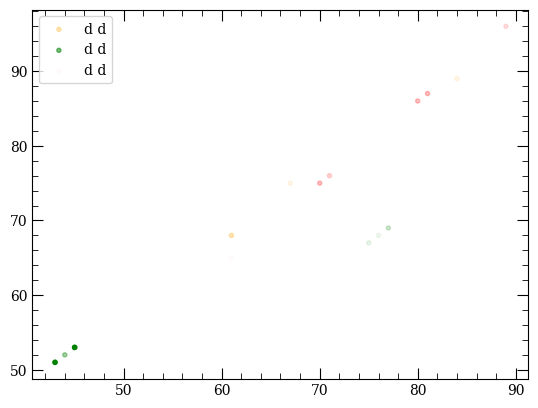

In [ ]:


plot_n1s=[]
plot_n2s=[]
defects=[]
fig, ax = plt.subplots(ncols=2)

col = 0

ns = np.arange(40,91,1)
ns1 =np.arange(40,91,1)
l1, l2 = 1, 1
j1, j2 = 3/2, 3/2

theta, phi = 0, 0
dn = 6
deltamax = 1e10
def flatten(xs):
    result = []
    if isinstance(xs, (list, tuple)):
        for x in xs:
            result.extend(flatten(x))
    else:
        result.append(xs)
    return result

for l1_1 in [l1-1, l1+1]:
    for l2_1 in [l2-1, l1+1]:
        path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
        if os.path.exists(path):
            df = pd.read_excel(path)
            if len(df) == 0:
                continue
            plot_n1s.append(df['n1_0'].to_numpy())
            plot_n2s.append(df['n2_0'].to_numpy())
            defects.append(df['defect'].to_numpy())
            
            
            col+=1
        else:
            continue

norm = max(np.concatenate(defects), key=abs)
defects1=[]
for i, defect in enumerate(defects):
    print(defect)
    defects1 = abs(np.array(defect))/abs(norm)
    ax.scatter(plot_n1s[i], plot_n2s[i], marker='.', color=colours[i], label = f'{orbs[l1_1]} {orbs[l2_1]}', alpha = (defects1))
plt.legend()
plt.colorbar(alpha = 1)
